# ---- AAPL ----

### a. eksplorasi data

Pada tahap ini dilakukan eksplorasi terhadap dataset menggunakan kolom Date dan Close untuk memahami pola perubahan harga saham dari waktu ke waktu. Selanjutnya data diurutkan berdasarkan tanggal, dinormalisasi menggunakan MinMaxScaler, kemudian dibentuk menjadi pasangan input-output menggunakan metode sliding window dengan window size = 5 dan horizon = 1. Data kemudian dipisahkan menjadi train, validation (90:10), dan test dengan data test menggunakan periode satu tahun terakhir agar sesuai dengan karakteristik data time series.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [2]:
# LOAD DATA
df = pd.read_csv("AAPL.csv")
df = df[["Date", "Close"]]
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)


        Date     Close
0 1980-12-12  0.513393
1 1980-12-15  0.486607
2 1980-12-16  0.450893
3 1980-12-17  0.462054
4 1980-12-18  0.475446
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9909 non-null   datetime64[ns]
 1   Close   9909 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 155.0 KB
None
Date     0
Close    0
dtype: int64


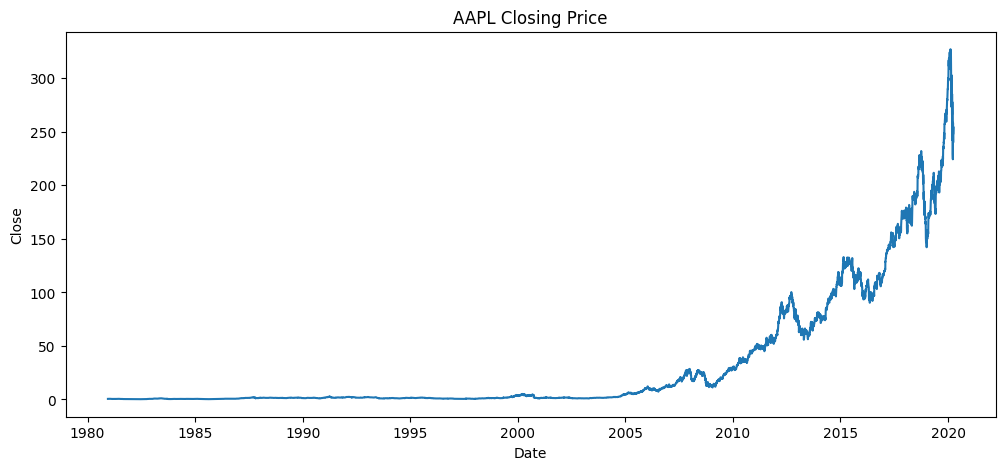

In [3]:
# EDA
print(df.head())
print(df.info())
print(df.isnull().sum())

plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Close"])
plt.title("AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Close")
plt.show()

In [4]:
# TRAIN TEST SPLIT
# Test = 1 tahun terakhir

last_date = df["Date"].max()

cutoff_date = last_date - pd.DateOffset(years=1)
train_full_df = df[df["Date"] < cutoff_date]
test_df = df[df["Date"] >= cutoff_date]
 
# TRAIN VALIDATION SPLIT
# 90 : 10

val_size = int(len(train_full_df) * 0.10)

train_df = train_full_df.iloc[:-val_size]
val_df = train_full_df.iloc[-val_size:]

print("Train :", len(train_df))
print("Val   :", len(val_df))
print("Test  :", len(test_df))

 
# SCALING

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df[["Close"]])
val_scaled = scaler.transform(val_df[["Close"]])
test_scaled = scaler.transform(test_df[["Close"]])

Train : 8690
Val   : 965
Test  : 254


tidak ada data null

test = 254 karena dalam 1 tahun hanya ada 254 hari dimana bursa saham dibuka

In [ ]:
# WINDOWING

WINDOW_SIZE = 5
HORIZON = 1

def make_windows(series, window_size=5, horizon=1):
    X = []
    y = []

    for i in range(len(series) - window_size - horizon + 1):
        X.append(series[i:i+window_size])

        y.append(
            series[
                i+window_size :
                i+window_size+horizon
            ]
        )

    return np.array(X), np.array(y)


# TRAIN

X_train, y_train = make_windows(
    train_scaled.flatten(),
    WINDOW_SIZE,
    HORIZON
)


# VALIDATION
# pakai 5 hari terakhir train

val_series = np.concatenate([
    train_scaled[-WINDOW_SIZE:],
    val_scaled
]).flatten()

X_val, y_val = make_windows(
    val_series,
    WINDOW_SIZE,
    HORIZON
)


# TEST

test_series = np.concatenate([
    val_scaled[-WINDOW_SIZE:],
    test_scaled
]).flatten()

X_test, y_test = make_windows(
    test_series,
    WINDOW_SIZE,
    HORIZON
)

 
# RESHAPE sesuai dengan kebutuhan LSTM

X_train = X_train.reshape(
    X_train.shape[0],
    WINDOW_SIZE,
    1
)

X_val = X_val.reshape(
    X_val.shape[0],
    WINDOW_SIZE,
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    WINDOW_SIZE,
    1
)


### b. Baseline LSTM

Model baseline dibangun menggunakan 1 layer LSTM dengan 50 unit dan fungsi aktivasi ReLU, kemudian diikuti oleh 1 layer Dense dengan 1 neuron sebagai output prediksi harga saham. Model dilatih menggunakan optimizer Adam dan fungsi loss Mean Squared Error (MSE) untuk mempelajari hubungan antara harga saham lima hari sebelumnya dengan harga saham hari berikutnya.



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 50)                10400     
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 10451 (40.82 KB)
Trainable params: 10451 (40.82 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/20


272/272 [==============================] - 2s 3ms/step - loss: 0.0057 - mae: 0.0217 - val_loss: 0.0062 - val_mae: 0.0492
Epoch 2/20
272/272 [==============================] - 1s 2ms/step - loss: 3.4310e-05 - mae: 0.0029 - val_loss: 0.0077 - val_mae: 0.0564
Epoch 3/20
272/272 [==============================] - 1s 2ms/step - loss: 3.5241e-05 - mae: 0.0031 - val_loss: 0.0069 - val_mae: 0.0526
Epoch 4/

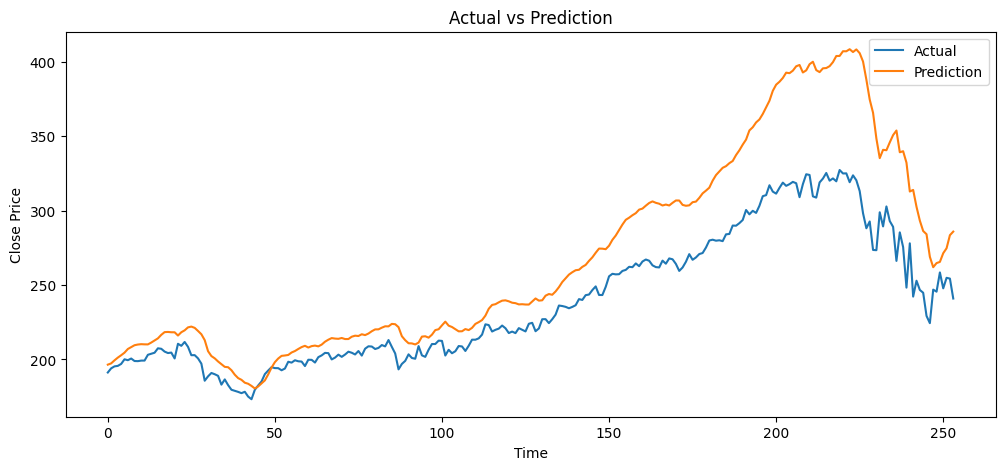

In [6]:
# BASELINE LSTM
 

tf.random.set_seed(42)

model = Sequential([
    LSTM(
        units=50,
        activation="relu",
        input_shape=(WINDOW_SIZE,1)
    ),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

 
# TRAINING

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)
 
# PREDICTION

y_pred = model.predict(X_test)
 
# INVERSE TRANSFORM
 

y_pred_actual = scaler.inverse_transform(y_pred)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)
 
# VISUALIZATION
 
plt.figure(figsize=(12,5))

plt.plot(
    y_test_actual,
    label="Actual"
)

plt.plot(
    y_pred_actual,
    label="Prediction"
)

plt.title("Actual vs Prediction")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

### c. Modifikasi arsitektur

* Menambahkan layer LSTM kedua

  Pada model baseline hanya terdapat satu layer LSTM dengan 50 unit. Arsitektur tersebut sudah mampu menangkap pola temporal sederhana, tetapi masih memiliki keterbatasan dalam mempelajari pola pergerakan harga saham yang lebih kompleks. Oleh karena itu ditambahkan layer LSTM kedua sehingga model dapat mempelajari representasi data secara bertingkat dan menangkap pola jangka pendek maupun jangka panjang dengan lebih baik.

* Meningkatkan jumlah unit pada layer LSTM pertama menjadi 64

  Pada model baseline digunakan 50 unit LSTM. Jumlah unit yang relatif sedikit dapat membatasi kapasitas model dalam menyimpan informasi historis yang penting. Dengan meningkatkan jumlah unit menjadi 64, model memiliki kemampuan yang lebih besar untuk mempelajari karakteristik data time series dan menghasilkan representasi yang lebih informatif.

* Menambahkan Dropout sebesar 0.2

  Setelah penambahan layer dan neuron, jumlah parameter pada model meningkat sehingga risiko overfitting menjadi lebih besar. Oleh karena itu ditambahkan Dropout sebesar 20% untuk membantu proses regularisasi. Sekarang, model jadi mampu melakukan generalisasi dengan lebih baik pada data yang belum pernah dilihat sebelumnya.

* Menambahkan Dense layer dengan 16 neuron dan aktivasi ReLU

  Pada model baseline, output LSTM langsung dihubungkan ke layer prediksi. Tapi ini terkadang kurang optimal karena model memiliki ruang yang terbatas untuk mempelajari hubungan non-linear yang lebih kompleks. Dengan menambahkan Dense layer, model dapat melakukan transformasi fitur tambahan sebelum menghasilkan nilai prediksi akhir.

* Menggunakan Early Stopping

  Pada model baseline proses training berjalan sesuai jumlah epoch yang ditentukan tanpa mempertimbangkan apakah model masih mengalami peningkatan performa atau tidak. Hal ini berpotensi menyebabkan overfitting. Oleh karena itu pakai Early Stopping untuk menghentikan training secara otomatis ketika validation loss tidak lagi membaik, sehingga model yang diperoleh lebih optimal.


In [7]:
model_improved = Sequential([

    LSTM(
        64,
        activation='relu',
        return_sequences=True,
        input_shape=(WINDOW_SIZE,1)
    ),

    tf.keras.layers.Dropout(0.2),

    LSTM(
        32,
        activation='relu'
    ),

    Dense(16, activation='relu'),

    Dense(1)

])

model_improved.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='mse',
    metrics=['mae']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_improved = model_improved.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
272/272 [==============================] - 3s 5ms/step - loss: 0.0052 - mae: 0.0272 - val_loss: 0.0256 - val_mae: 0.1032
Epoch 2/100
272/272 [==============================] - 1s 4ms/step - loss: 2.8022e-04 - mae: 0.0092 - val_loss: 0.0073 - val_mae: 0.0535
Epoch 3/100
272/272 [==============================] - 1s 4ms/step - loss: 2.5613e-04 - mae: 0.0090 - val_loss: 0.0040 - val_mae: 0.0405
Epoch 4/100
272/272 [==============================] - 1s 4ms/step - loss: 2.1421e-04 - mae: 0.0082 - val_loss: 0.0045 - val_mae: 0.0427
Epoch 5/100
272/272 [==============================] - 1s 4ms/step - loss: 1.7253e-04 - mae: 0.0072 - val_loss: 0.0046 - val_mae: 0.0482
Epoch 6/100
272/272 [==============================] - 1s 4ms/step - loss: 1.8670e-04 - mae: 0.0077 - val_loss: 0.0016 - val_mae: 0.0272
Epoch 7/100
272/272 [==============================] - 1s 4ms/step - loss: 1.4939e-04 - mae: 0.0068 - val_loss: 0.0012 - val_mae: 0.0268
Epoch 8/100
272/272 [========================

### d. Evaluasi

In [8]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    ) * 100

    return rmse, mae, mape

In [9]:
baseline_pred = model.predict(X_test)

baseline_pred = scaler.inverse_transform(
    baseline_pred
)

rmse_base, mae_base, mape_base = evaluate_model(
    y_test_actual,
    baseline_pred
)

improved_pred = model_improved.predict(
    X_test
)

improved_pred = scaler.inverse_transform(
    improved_pred
)

rmse_imp, mae_imp, mape_imp = evaluate_model(
    y_test_actual,
    improved_pred
)

8/8 [==============================] - 0s 2ms/step


In [10]:
result = pd.DataFrame({

    "Model":[
        "Baseline LSTM",
        "Improved LSTM"
    ],

    "RMSE":[
        rmse_base,
        rmse_imp
    ],

    "MAE":[
        mae_base,
        mae_imp
    ],

    "MAPE (%)":[
        mape_base,
        mape_imp
    ]

})

print(result)

           Model       RMSE        MAE   MAPE (%)
0  Baseline LSTM  38.798250  29.566538  11.196568
1  Improved LSTM   8.817027   6.059281   2.557864


* RMSE menurun sebesar 77,27% dari Baseline LSTM (38.80 → 8.82)
* MAE menurun sebesar 79,51% dari Baseline LSTM (29.57 → 6.06)
* MAPE menurun sebesar 77,15% dari Baseline LSTM (11.20% → 2.56%)


Berdasarkan hasil evaluasi pada test set menggunakan dataset Apple Inc. (AAPL), terlihat bahwa Improved LSTM memberikan performa yang jauh lebih baik dibandingkan Baseline LSTM pada seluruh metrik evaluasi. Nilai RMSE berhasil diturunkan dari 38.80 menjadi 8.82, atau mengalami penurunan sekitar 77,27%, yang menunjukkan bahwa kesalahan prediksi model menjadi jauh lebih kecil dan model lebih mampu mengurangi error yang besar. Selain itu, nilai MAE juga turun dari 29.57 menjadi 6.06, atau berkurang sekitar 79,51%, yang berarti rata-rata selisih antara hasil prediksi dan harga saham sebenarnya menjadi jauh lebih kecil. Penurunan pada kedua metrik ini menunjukkan bahwa hasil prediksi Improved LSTM lebih akurat dan lebih konsisten dibandingkan model baseline.

Hal yang sama juga terlihat pada metrik MAPE, di mana nilainya menurun dari 11.20% menjadi 2.56%, atau sekitar 77,15% lebih rendah dibandingkan Baseline LSTM. Artinya, rata-rata kesalahan prediksi relatif terhadap harga saham sebenarnya hanya sekitar 2,56%, sehingga model mampu mengikuti pola pergerakan harga saham AAPL dengan tingkat akurasi yang tinggi. Secara keseluruhan, penurunan nilai RMSE, MAE, dan MAPE yang konsisten membuktikan bahwa modifikasi arsitektur serta proses tuning hyperparameter pada Improved LSTM berhasil meningkatkan kemampuan model dalam mempelajari pola historis data. Oleh karena itu, Improved LSTM dapat disimpulkan sebagai model yang lebih akurat, lebih stabil, dan lebih layak digunakan untuk prediksi harga saham dibandingkan Baseline LSTM.


8/8 [==============================] - 0s 2ms/step


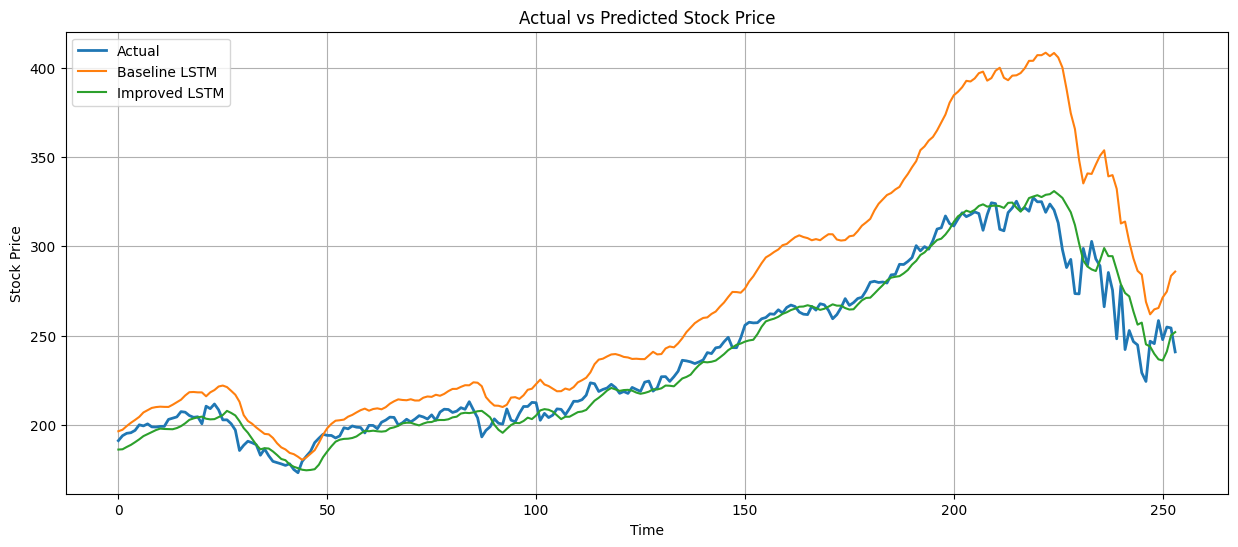

In [11]:

# Baseline Prediction
baseline_pred = model.predict(X_test)
baseline_pred_actual = scaler.inverse_transform(baseline_pred)

# Improved Prediction
improved_pred = model_improved.predict(X_test)
improved_pred_actual = scaler.inverse_transform(improved_pred)


# Combined Plot
plt.figure(figsize=(15,6))
plt.plot(
    y_test_actual,
    label="Actual",
    linewidth=2
)
plt.plot(
    baseline_pred_actual,
    label="Baseline LSTM"
)
plt.plot(
    improved_pred_actual,
    label="Improved LSTM"
)

plt.title("Actual vs Predicted Stock Price")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.show()